In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WhatsApp Image 2026-04-03 at 4.55.54 PM (1).jpeg to WhatsApp Image 2026-04-03 at 4.55.54 PM (1).jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.54 PM (2).jpeg to WhatsApp Image 2026-04-03 at 4.55.54 PM (2).jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.54 PM.jpeg to WhatsApp Image 2026-04-03 at 4.55.54 PM.jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.55 PM (1).jpeg to WhatsApp Image 2026-04-03 at 4.55.55 PM (1).jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.55 PM (2).jpeg to WhatsApp Image 2026-04-03 at 4.55.55 PM (2).jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.55 PM.jpeg to WhatsApp Image 2026-04-03 at 4.55.55 PM.jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.56 PM (1).jpeg to WhatsApp Image 2026-04-03 at 4.55.56 PM (1).jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.56 PM (2).jpeg to WhatsApp Image 2026-04-03 at 4.55.56 PM (2).jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.56 PM (3).jpeg to WhatsApp Image 2026-04-03 at 4.55.56 PM (3).jpeg
Saving WhatsApp Image 2026-04-03 at 4.55.56 

In [ ]:
import os

images = [f for f in os.listdir("/content") if f.endswith((".png", ".jpg", ".jpeg"))]

print("Images found:", images)

Images found: ['WhatsApp Image 2026-04-03 at 4.55.55 PM (2).jpeg', 'WhatsApp Image 2026-04-03 at 4.55.55 PM.jpeg', 'WhatsApp Image 2026-04-03 at 4.55.56 PM (2).jpeg', 'WhatsApp Image 2026-04-03 at 4.55.56 PM (3).jpeg', 'WhatsApp Image 2026-04-03 at 4.55.55 PM (1).jpeg', 'WhatsApp Image 2026-04-03 at 4.55.54 PM.jpeg', 'WhatsApp Image 2026-04-03 at 4.55.54 PM (1).jpeg', 'WhatsApp Image 2026-04-03 at 4.55.54 PM (2).jpeg', 'WhatsApp Image 2026-04-03 at 4.55.56 PM (1).jpeg', 'WhatsApp Image 2026-04-03 at 4.55.56 PM.jpeg']


In [ ]:
import cv2
import numpy as np

def create_mask(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray,120,255,cv2.THRESH_BINARY_INV)
    return mask

In [ ]:
def healing(mask):
    kernel = np.ones((7,7),np.uint8)
    return [
        mask,
        cv2.erode(mask,kernel,2),
        cv2.erode(mask,kernel,4),
        cv2.erode(mask,kernel,6)
    ]

def non_healing(mask):
    kernel = np.ones((5,5),np.uint8)
    return [
        mask,
        cv2.erode(mask,kernel,1),
        cv2.dilate(mask,kernel,1),
        mask
    ]

In [ ]:
import os

image_dir = "/content"

for i, img in enumerate(images):
    path = os.path.join(image_dir, img)
    m0 = create_mask(path)

    if i % 2 == 0:
        seq = healing(m0)
        label_type = "healing"
    else:
        seq = non_healing(m0)
        label_type = "non_healing"

    wid = f"W{i}"
    mask_store[wid] = seq

    for d,m in zip(days,seq):
        area = np.sum(m==255)
        data.append([wid,d,area,label_type])

df = pd.DataFrame(data,columns=["wound_id","day","area","type"])

In [ ]:
import pandas as pd
import numpy as np

features = []

for w,g in df.groupby("wound_id"):
    g = g.sort_values("day")
    areas = g["area"].values

    initial = areas[0]
    final = areas[-1]

    reduction = (initial-final)/initial

    label = 1 if g["type"].iloc[0] == "healing" else 0

    features.append([
        w,
        initial,
        final,
        reduction,
        np.mean(areas),
        np.std(areas),
        label
    ])

features_df = pd.DataFrame(features,columns=[
    "wound_id","initial","final","reduction","mean","std","label"
])

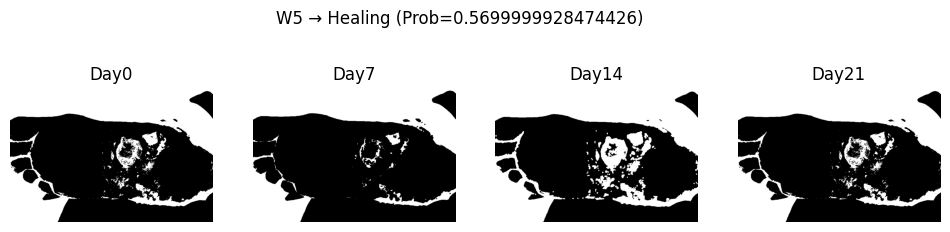

In [ ]:
balanced = features_df
from sklearn.model_selection import train_test_split
import xgboost as xgb

X = balanced.drop(["wound_id","label"],axis=1)
y = balanced["label"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,stratify=y,random_state=42
    )

model = xgb.XGBClassifier()
model.fit(X_train,y_train)
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]
import matplotlib.pyplot as plt

if len(mask_store) > 0:
    wid = list(mask_store.keys())[5]
    seq = mask_store[wid]

    sample = features_df[features_df.wound_id==wid].drop(["wound_id","label"],axis=1)

    # Check if sample is not empty before prediction
    if not sample.empty:
        p = model.predict_proba(sample)[0][1]

        result = "Healing" if p>0.5 else "Non-Healing"

        plt.figure(figsize=(12,3))
        titles = ["Day0","Day7","Day14","Day21"]

        for i,m in enumerate(seq):
            plt.subplot(1,4,i+1)
            plt.imshow(m,cmap="gray")
            plt.title(titles[i])
            plt.axis("off")

        plt.suptitle(f"{wid} → {result} (Prob={round(p,2)})")
        plt.show()
    else:
        print(f"No sample data found for wound_id: {wid}")
else:
    print("mask_store is empty. Cannot visualize.")

In [ ]:
print(features_df["label"].value_counts())

label
1    11
0    10
Name: count, dtype: int64


In [ ]:
print(features_df)
print("\nLabel count:")
print(features_df["label"].value_counts())

   wound_id  initial   final  reduction       mean           std  label
0        W0   260447  226639   0.129808  235091.00  14639.293426      1
1        W1   424558  424558   0.000000  424146.75  31396.466834      0
2       W10    35294   23114   0.345101   26159.00   5274.094709      1
3       W11   273516  273516   0.000000  273986.25  15791.394435      0
4       W12   245700  213237   0.132125  221352.75  14056.891342      1
5       W13   500993  500993   0.000000  502609.00  36540.845557      0
6       W14   245700  213237   0.132125  221352.75  14056.891342      1
7       W15   260447  260447   0.000000  261631.75  19814.288750      0
8       W16    80606   71014   0.118999   73412.00   4153.457837      1
9       W17    80606   80606   0.000000   80747.25   5222.126453      0
10      W18    21959    8757   0.601211   12057.50   5716.633690      1
11      W19   500993  500993   0.000000  502609.00  36540.845557      0
12       W2   375546  255363   0.320022  285408.75  52040.765552